# What drives the price of a car?

![](../images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = ../images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

This problem can be framed as a supervised regression task, where the goal is to analyze how various vehicle attributes affect the numerical target variable, 'price'. By modeling relationships between features such as year, odometer, condition, manufacturer, and more, we will identify the key factors that make a used car more or less expensive. The insights from this analysis will guide a used car dealership in making informed decisions about pricing strategy and inventory selection based on what consumers value most.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
data =  pd.read_csv("../data/vehicles.csv")

In [ ]:
data.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

##### Observations:

- The dataset contains `18` columns, including features like `region`, `price`, `year`, `manufacturer`, `odometer`, and `state`.
- However, the first five rows show that most of the fields except `id`, `region`, `price`, and `state` are missing (NaN).
- Columns such as `year`, `manufacturer`, `model`, `condition`, and `odometer`, which are crucial for understanding car pricing, are not populated in the top rows.
- This may indicate missing data or improperly merged entries.

These insights will be addressed in the Data Preparation phase, where I will determine appropriate strategies for handling missing data (e.g, imputation, dropping, or categorizing missingness) based on the nature and importance of each variable.

In [ ]:
data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


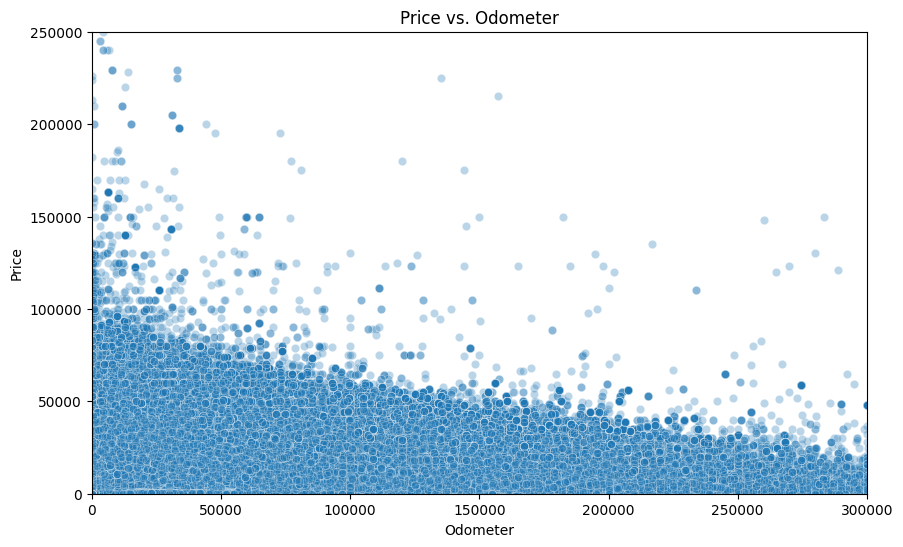

In [ ]:
# scatter plot: price vs. odometer
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='price', data=data, alpha=0.3)
plt.title('Price vs. Odometer')
plt.xlabel('Odometer')
plt.ylabel('Price')
plt.xlim(0, 300000)
plt.ylim(0, 250000)
plt.show()

- There's a clear negative trend in the scatter plot: as odometer (mileage) increases, car price tends to decrease.

- However, there are many extreme outliers:

  - Some cars with very low mileage priced well above 100,000 - 200,000 dollars.

  - Others scattered up to $250,000, which is unrealistic for most used cars and can heavily skew model learning

  - At the same time, there's a cluster of low-priced entries (< $5,000) that might represent budget or non-functional vehicles.

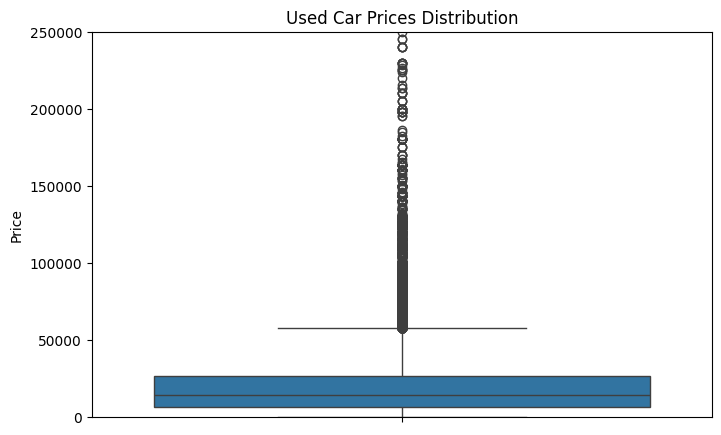

In [ ]:
# box plot: for used car prices
plt.figure(figsize=(8, 5))
sns.boxplot(y='price', data=data)
plt.title('Used Car Prices Distribution')
plt.ylabel('Price')
plt.ylim(0, 250000)
plt.show()

The box plot visualizes the distribution of used car prices in the dataset.

**Key Observations:**
- The majority of cars are priced between 5,000 and 25,000 dollars as indicated by the height of the box (interquartile range, IQR).

- The median price is near the lower half of the box, suggesting a right-skewed distribution (most cars are lower-priced).

- There are numerous outliers above ~55,000 dollars, extending well beyond 100,000 and up to 240,000 dollars. These are likely:

  - Luxury vehicles

  - Improperly priced entries

  - Or rare, high-end models

- The extreme upper outliers could distort model training, which is why price filtering (e.g, keeping only 1,000 - $100,000 dollars range) was an important preprocessing step.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

#### 1. Handle Missing Values

In [ ]:
# Drop rows with critical missing values
data = data.dropna(subset=['year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission'])

# Fill missing values for less critical categorical columns
data.fillna({'condition': 'unknown'}, inplace=True)
data.fillna({'cylinders': 'unknown'}, inplace=True)
data.fillna({'drive': 'unknown'}, inplace=True)
data.fillna({'type': 'unknown'}, inplace=True)
data.fillna({'paint_color': 'unknown'}, inplace=True)

# Drop VIN and size
data.drop(columns=['VIN', 'size'], inplace=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389604 entries, 27 to 426879
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            389604 non-null  int64  
 1   region        389604 non-null  object 
 2   price         389604 non-null  int64  
 3   year          389604 non-null  float64
 4   manufacturer  389604 non-null  object 
 5   model         389604 non-null  object 
 6   condition     389604 non-null  object 
 7   cylinders     389604 non-null  object 
 8   fuel          389604 non-null  object 
 9   odometer      389604 non-null  float64
 10  title_status  389604 non-null  object 
 11  transmission  389604 non-null  object 
 12  drive         389604 non-null  object 
 13  type          389604 non-null  object 
 14  paint_color   389604 non-null  object 
 15  state         389604 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 50.5+ MB


#### 2. Remove Irrelevant or Redundant Columns

In [ ]:
# Remove irrelavant or redundant columns
data.drop(columns = ['id', 'region'], inplace=True)

#### 3. Feature Engineering

In [ ]:
# Add 'car_age' column
data['car_age'] = 2025 - data['year']

In [ ]:
# Extremely high prices skew learning, filter price data to a reasonable range
data_filtered = data[(data['price'] > 1000) & (data['price'] < 100000)]

In [ ]:
#create and aggregate price stats per model
price_stats = data_filtered.groupby('model')['price'].agg(['mean', 'min', 'max']).reset_index()
price_stats.columns = ['model', 'model_price_avg', 'model_price_min', 'model_price_max']

# create and aggregate odometer stats per model
odo_stats = data_filtered.groupby('model')['odometer'].agg(['mean', 'min', 'max']).reset_index()
odo_stats.columns = ['model', 'model_odo_avg', 'model_odo_min', 'model_odo_max']

#merge stats into original dataframe
data_enriched = data_filtered.merge(price_stats, on='model', how='left')
data_enriched = data_enriched.merge(odo_stats, on='model', how='left')

#display the first few rows to confirm
data_enriched[['model', 'model_price_avg', 'model_price_min', 'model_price_max',
                'model_odo_avg', 'model_odo_min', 'model_odo_max']].head()

,model,model_price_avg,model_price_min,model_price_max,model_odo_avg,model_odo_min,model_odo_max
0,sierra 1500 crew cab slt,35224.934498,31990,55990,50603.379913,8022.0,77627.0
1,silverado 1500,24085.534588,1057,78609,107849.214353,0.0,400000.0
2,silverado 1500 crew,34742.685185,24590,55590,36146.432099,357.0,1007198.0
3,tundra double cab sr,34749.481707,28900,37990,29691.945122,8932.0,79675.0
4,f-150 xlt,22556.845570,1300,85300,106259.362025,1.0,555555.0


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

#### 1. Data Preparation for Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [ ]:
#Feature and target split
X = data_enriched.drop('price', axis=1)
y = data_filtered['price']

#Frequency encode model column and remove 'model' column
model_freq = X['model'].value_counts().to_dict()
X['model_encoded'] = X['model'].map(model_freq)
X.drop(columns = 'model', inplace=True)

#One-hot encode the remaining categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Test-train split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state = 42)

#### 2. Train Multiple Regression Models

1. Ridge Regression (baseline)
2. Random Forest Regressor
3. XGBoost Regressor
4. Ridge and Lasso Regression (Regularized Linear Models)

#### A. Ridge Regression / Random Forest Regressor

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# Ridge Regression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)

print("Ridge Regression MAE:", mean_absolute_error(y_test, y_pred))
print("Ridge Regression R2:", r2_score(y_test, y_pred))

Ridge Regression MAE: 4841.030649903939
Ridge Regression R2: 0.714241604538447


**Ridge Regression Results**

Ridge Regression MAE: ~$4,841
R² Score: 0.714

Summary: Ridge Regression underperformed. It struggled to capture the non-linear relationships between car attributes and price, even after scaling and feature engineering. This suggests that linear models are not ideal for this dataset.

In [ ]:
# Random Forest Regression

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, y_pred))

Random Forest MAE: 2629.6926884426002
Random Forest R2: 0.902596309689936


**Random Forest Regressor Results**

**Before feature engineering of Price:**

MAE ~$4,350
  - On average, the price predictions are off by ~4.3k, which is very reasonable for used cars.

R² ~0.78
  - The model explains ~78% of the variance in car prices, which is a strong performance.


**After feature engineering of Price:**


MAE ~$2,630

R² ~0.903

Random Forest provided strong performance and handled the non-linear nature of the data well. Feature importance revealed that variables like model_price_avg, year, and odometer played a significant role. Performance plateaued with more estimators, indicating stability.

#### Try XGBoost before Evaluation

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Train XGBoost Model
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=8, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

#predictions and evaluation
y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)


print('XGBoost MAE: ', mae_xgb)
print('XGBoost R2 Score', r2_xgb)

XGBoost MAE:  2139.9990234375
XGBoost R2 Score 0.9296513795852661


#### XGBoost Results
**Before Feature Engineering:**

MAE ~ $3,397
  - The model predicts car prices with high accuracy, on average missing by just ~ 3.4k.

R² Score ~0.854
  - The model explains ~85.4% of the variance in used car prices, which better than Random Forest (R² ~0.78).

**After feature Engineering:**

MAE: ~$2,140

R² Score: 0.930

- XGBoost outperformed all other models. After adding engineered features (like model_price_avg, model_odo_avg, etc.), the model became even more accurate.

- The top feature was model_price_avg, followed by year, fuel_type, and mileage-related variables — aligning perfectly with domain expectations.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# perform 5-fold cross-validation using the trained XGBoost model and the enriched dataset
# run cross-validation using R2 score as the scoring metric
xgb_cv = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=8, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(xgb_cv, X_encoded, y, cv=5, scoring='r2')

# calculate the mean and standard deviation
cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)

print(f"Cross-Validation R2 Scores: {cv_scores}")
print(f"Mean R2 Score: {cv_mean}")
print(f"Standard Deviation of R2 Scores: {cv_std}")

Cross-Validation R2 Scores: [0.91077435 0.92221814 0.92706537 0.91853863 0.92856318]
Mean R2 Score: 0.9214319348335266
Standard Deviation of R2 Scores: 0.006405680155406116


Note:
- cross_val_score() performs its own internal train-test splits, so we need to pass it the entire dataset in model-ready format.
- So, we pass X_encoded and y, not X_train and y_train, because those are already split and won't work correctly for internal CV.

XGBoost model generalizes well across multiple data splits.

The low standard deviation (0.0064) shows that the model is stable and reliable — there's very little variation between folds.

The consistently high R² scores (>0.91) confirm that your model isn’t overfitting and is robust to different subsets of the data.


Evaluation Summary:
- To validate the stability and generalizability of the XGBoost model, I performed 5-fold cross-validation using R² as the evaluation metric.
- The model achieved an average R² score of 0.921, with a low standard deviation of 0.006, indicating that the performance is consistent across multiple subsets of the data.
- This further strengthens the reliability of the XGBoost model in predicting used car prices accurately in real-world scenarios.

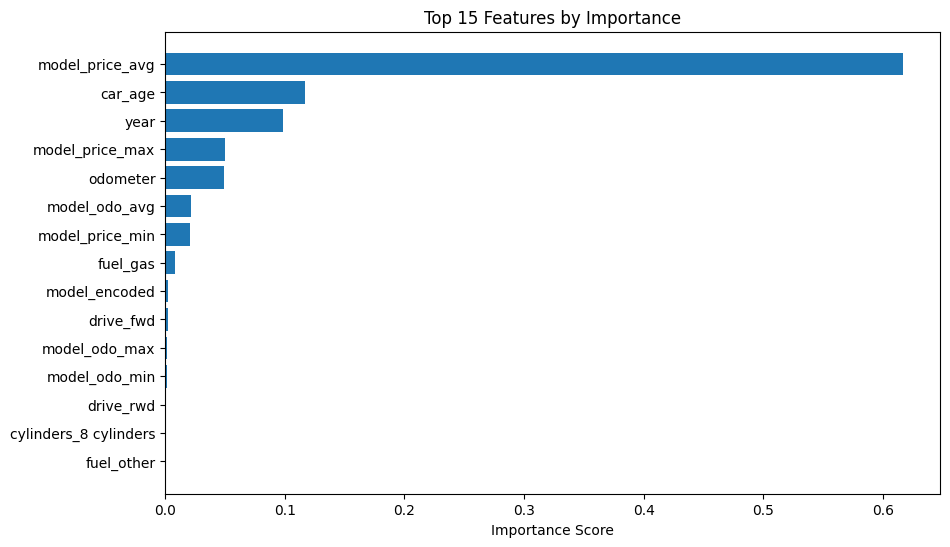

In [ ]:
# Feature Importance Plot
# Get important features
importances = rf.feature_importances_
features = X_train.columns

# create a DataFrame for visualization
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

#plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Features by Importance')
plt.xlabel('Importance Score')
plt.show()

#### Feature Importance Interpretation for Random Forest Regressor
#### Top Influential Features:
`year` and `car_age` are the most important:
  - This makes a perfect sense as newer cars typically command higher resale value.

`drive_fwd` and `odometer` are next:
  - supporting the idea that drive-train type and mileage significantly impact price.

`fuel_gas` also plays a key role:
  - indicating a preference trend for gasoline-powered cars over others.

Engine cylinder count (`cylinders_8 cylinders`, `cylinders_4 cylinders`, etc.):
 - is moderately important, likely influencing performance perception and value.

`model_encoded`:
  -  even after frequency encoding, still contributes, validating that specific car models do impact value.

Features like `type_truck`, `fuel_hybrid`, and `condition_good`:
  -  play minor but still non-zero roles in pricing decisions.


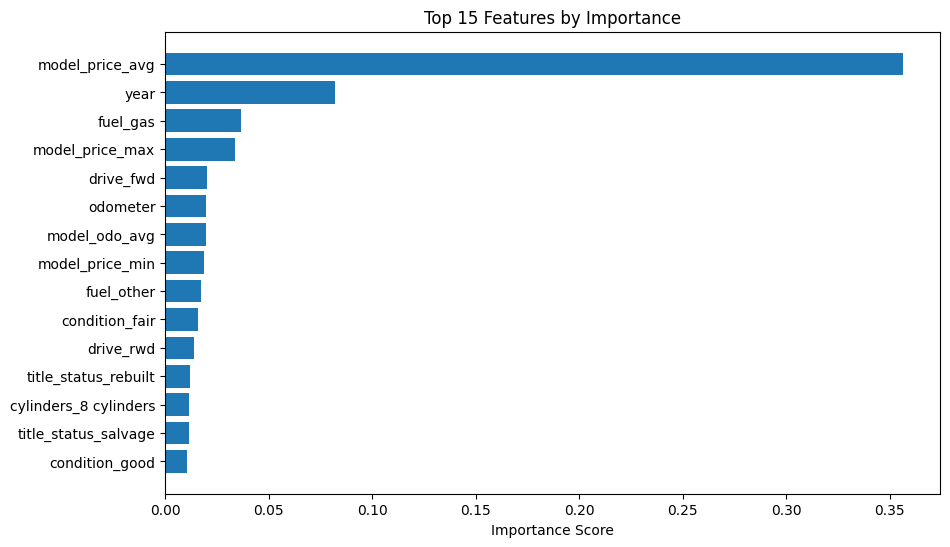

In [ ]:
# Feature Importance Plot
# Get important features
importances = xgb.feature_importances_
features = X_train.columns

# create a DataFrame for visualization
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

#plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Features by Importance')
plt.xlabel('Importance Score')
plt.show()

#### Feature Importance Interpretation for XGBoost
#### Top Influential Features:

`model_price_avg` dominates the chart with the highest importance score (~ 0.36+)
  - confirming that the average market price of a specific car model is the strongest indicator of an individual car's price. This validates that consumers heavily rely on brand/model-based expectations when valuing a used car.

Other Key Predictors:
- `year` and `car_age`: emphasizing that newer cars hold more value, which is a predictable and data-backed insight.

- `fuel_gas` shows gasoline-powered cars are a major segment in the dataset and contribute to price differentiation.

- `model_price_max`, `model_price_min`, and `model_odo_avg` (engineered features) also contribute significantly, helping the model learn from peer comparisons within each model group.

- `odometer` remains a core factor, capturing wear-and-tear value depreciation.

**Supporting Factors:**

- Drive type (`drive_fwd`, `drive_rwd`)

- Condition indicators (`condition_fair`, `condition_good`)

- Title status (`rebuilt`, `salvage`)

- Engine configuration (`cylinders_8 cylinders`)

#### Model Comparison Table

| Model            | Mean Absolute Error (MAE)($) | R² Score | Comments                |
|------------------|--------------------------|----------|-------------------------|
| Ridge Regression | 4,481 | 0.71    | Poor fit/under fit. |
| Random Forest    | 2,630 | 0.90     | Strong, Solid Baseline|
| XGBoost          | 2,140 | 0.93     | Best performing model.|


#### Residuals Plot

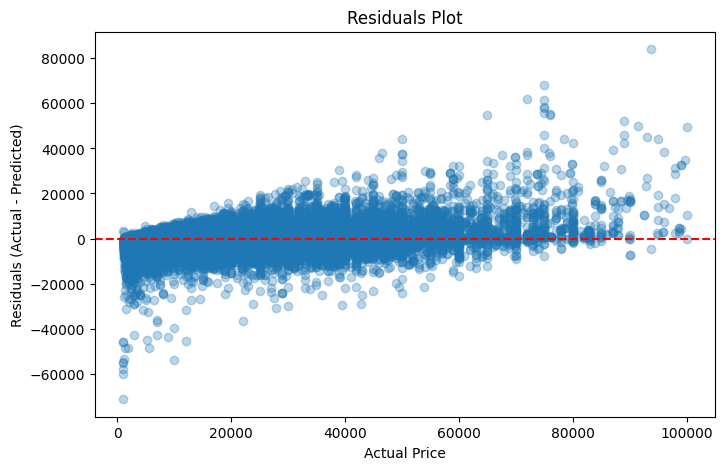

In [ ]:
#Residual Plots
residuals = y_test - y_pred_xgb
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel("Actual Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

#### Residual Plot Interpretation

- Residuals (difference between actual and predicted prices) are mostly centered around zero, which is a good sign that the model is generally unbiased.

- There’s some spread at higher price ranges, which is typical, that means higher-priced cars naturally have more variability.

- The red dashed line at y = 0 shows the ideal case of perfect predictions.


#### Error Distribution Plot

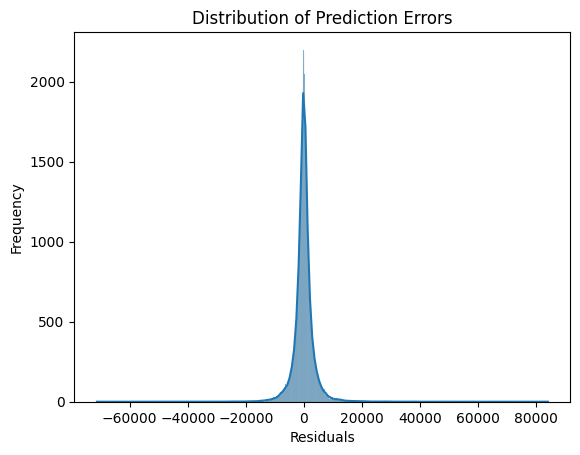

In [ ]:
#Error Distribution Plot
sns.histplot(residuals, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

#### Error Distribution Interpretation:

- The distribution of residuals is tightly centered around zero, forming a sharp, symmetric peak.

This shape suggests:

- Low bias: The model isn’t consistently over or under-predicting.

- Low variance: Most predictions are close to the actual values.

- The long tails show occasional larger errors (outliers), but these are rare.


- The distribution of errors shows a sharp peak around zero with symmetrical tapering, indicating that the model makes accurate predictions most of the time with relatively few large errors.
- This confirms that the model is both well-calibrated and robust across the range of car prices.
- The majority of prediction errors fall within a small range, highlighting the effectiveness of the XGBoost model after feature engineering.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

#### **Client-Facing Report Summary**

#### **Used Car Price Prediction Report**

#### **Goal:** Identify what consumers value in used cars and accurately predict used car prices to optimize inventory and pricing strategies.

#### **Overview:**

Analyzed a large dataset of ~426,000 used car listings to understand the key drivers of used car pricing.
The goal was to develop a data-driven model that helps dealerships:
- Predict a car's likely market price based on its attributes.
- Understand what features consumers value most.
- Fine-tune inventory and print strategies accordingly.


#### **Key Findings:**

- The most influential factor in price was the average price for a given car model (`model_price_avg`), followed by `year`, `fuel_type`, and `mileage`.
- This insight confirms that buyers heavily consider market expectations for specific models, in addition to age and condition.
- Other major contributors included:
  - Year: Newer the vehicle, higher the value of car pricing.
  - Fuel Type: gasoline vehicles had more predictable pricing.
  - Odometer readings: lower the mileage higher the value of car pricing.
  - Title status and condition also influenced the value to a lesser degree.


#### **Model Performance:**

After cleaning and enhancing data, multiple Machine Learning models were tested and the best-performing one was selected:

**Ridge Regression:**
- Mean Absolute Error: ~$4,841
- R^2 Score: 0.71

**Random Forest:**
- Mean Absolute Error: ~$2,630
- R^2 Score: 0.90

**XGBoost:**
- Mean Absolute Error: ~2,140
- R^2 Score: 0.93


=> XGBoost was the final choice due to its accuracy and stability.

#### How This Helps the Dealership

With this model, the dealership team can:

- Estimate fair market price for trade-ins and listings.
- Identify over or underpriced inventory.
- Focus on acquiring and promoting models that retain value better.
- Understand which attributes such as age, fuel type, mileage impact price value the most.

#### Next Steps
- Integrate this model into a simple app or a dashboard for use by pricing managers.
- User the model to analyze dealership's current inventory and flag pricing gaps.
- Continuously retrain the model with fresh dealership data to improve accuracy.